In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# DATA LOADING

In [ ]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from skimage.feature import hog
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



In [ ]:
# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Loading training data
train_images = load_images('/content/drive/MyDrive/PR_Lab1_Group1/DataSet_Fashion-MNIST/train-images-idx3-ubyte')
train_labels = load_labels('/content/drive/MyDrive/PR_Lab1_Group1/DataSet_Fashion-MNIST/train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('/content/drive/MyDrive/PR_Lab1_Group1/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte')
test_labels = load_labels('/content/drive/MyDrive/PR_Lab1_Group1/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


# PREPROCESSING

## Split, Normalize & Data augmentation

In [ ]:
# Split training data into training and validation sets (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

print("Training set size:", len(train_images))
print("Validation set size:", len(val_images))


Training set size: 48000
Validation set size: 12000


In [ ]:
# Nomalize data, scale to range between 0 and 1
scaler = MinMaxScaler()
train_images_scaled = scaler.fit_transform(train_images)
val_images_scaled = scaler.transform(val_images)
test_images_scaled = scaler.transform(test_images)


In [ ]:
train_images_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Drop and Rotation if possible and necessary...
# Define data augmentation
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28)
])

##  Exploratory Data Analysis (EDA)

### Show label

In [ ]:
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

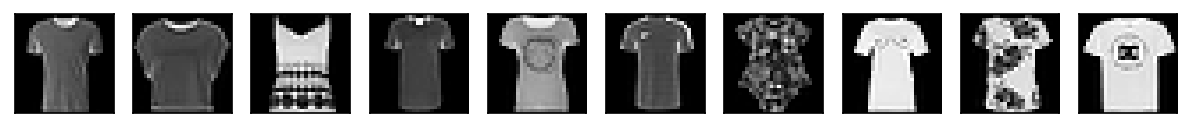

'label 1'

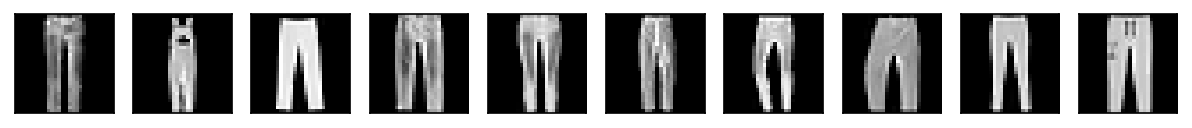

'label 2'

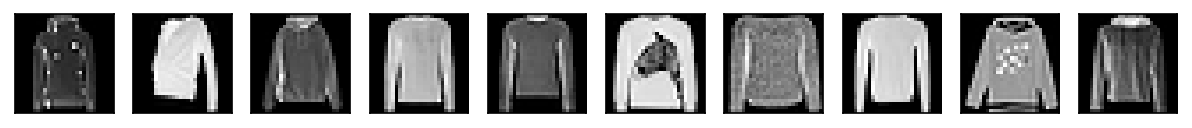

'label 3'

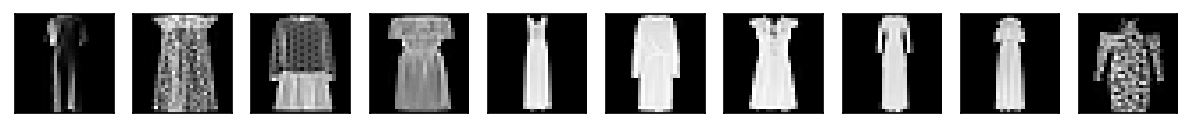

'label 4'

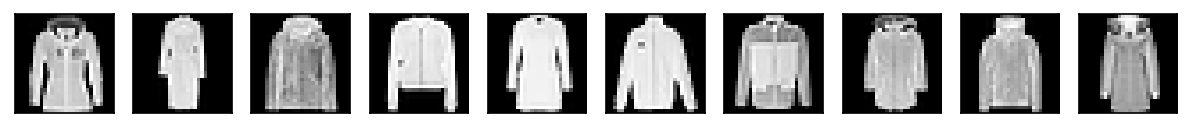

'label 5'

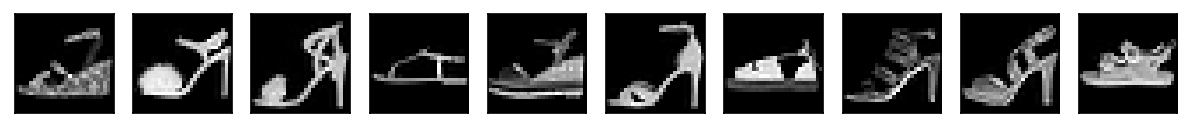

'label 6'

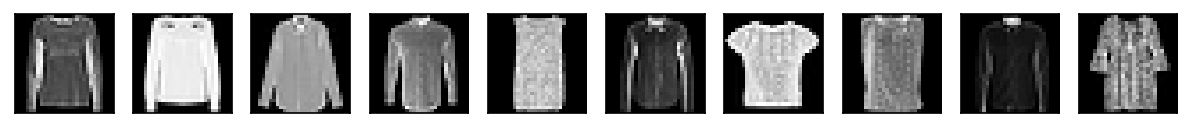

'label 7'

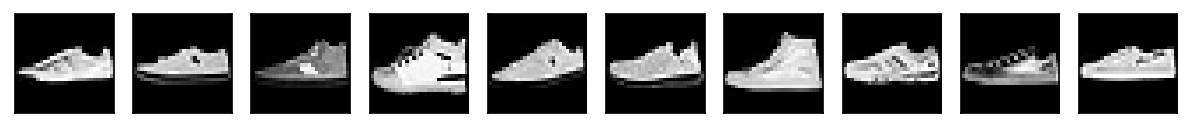

'label 8'

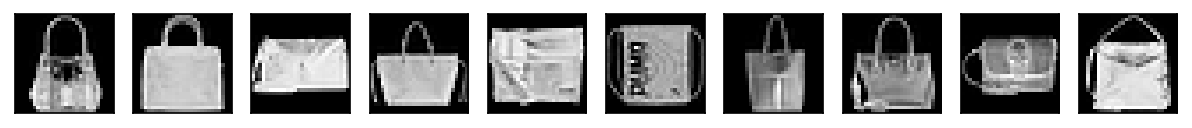

'label 9'

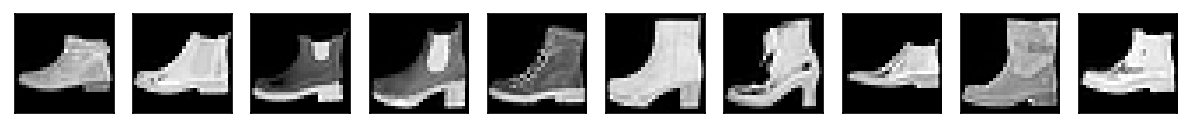

In [ ]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

### Displays distribution and frequency of the data

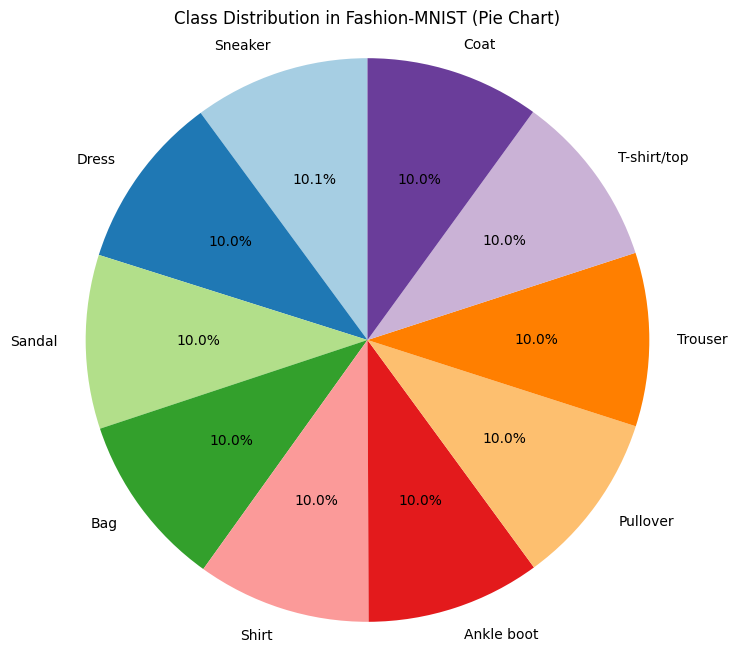

In [ ]:
# List of class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def pie_chart_class_distribution(labels):
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Class Distribution in Fashion-MNIST (Pie Chart)')
    plt.axis('equal')
    plt.show()

# Distribution of train_lables
pie_chart_class_distribution(train_labels)

> The number of each layer is the same => **The dataset is balanced**

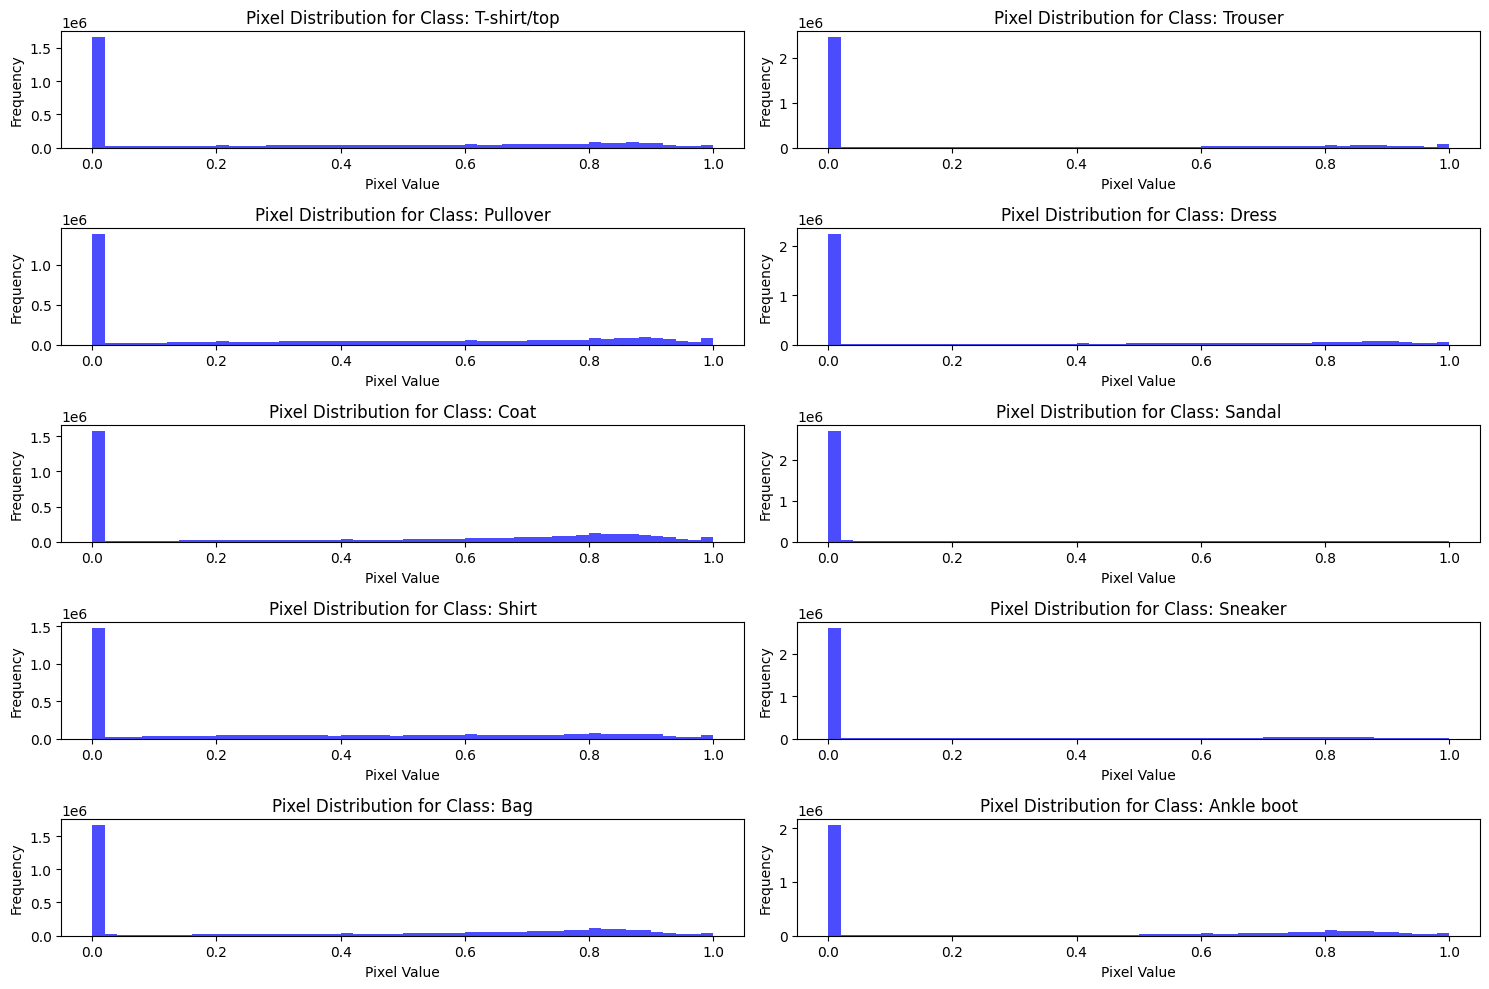

In [ ]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images_scaled, train_labels, class_names)


>We can see **values .0** that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.

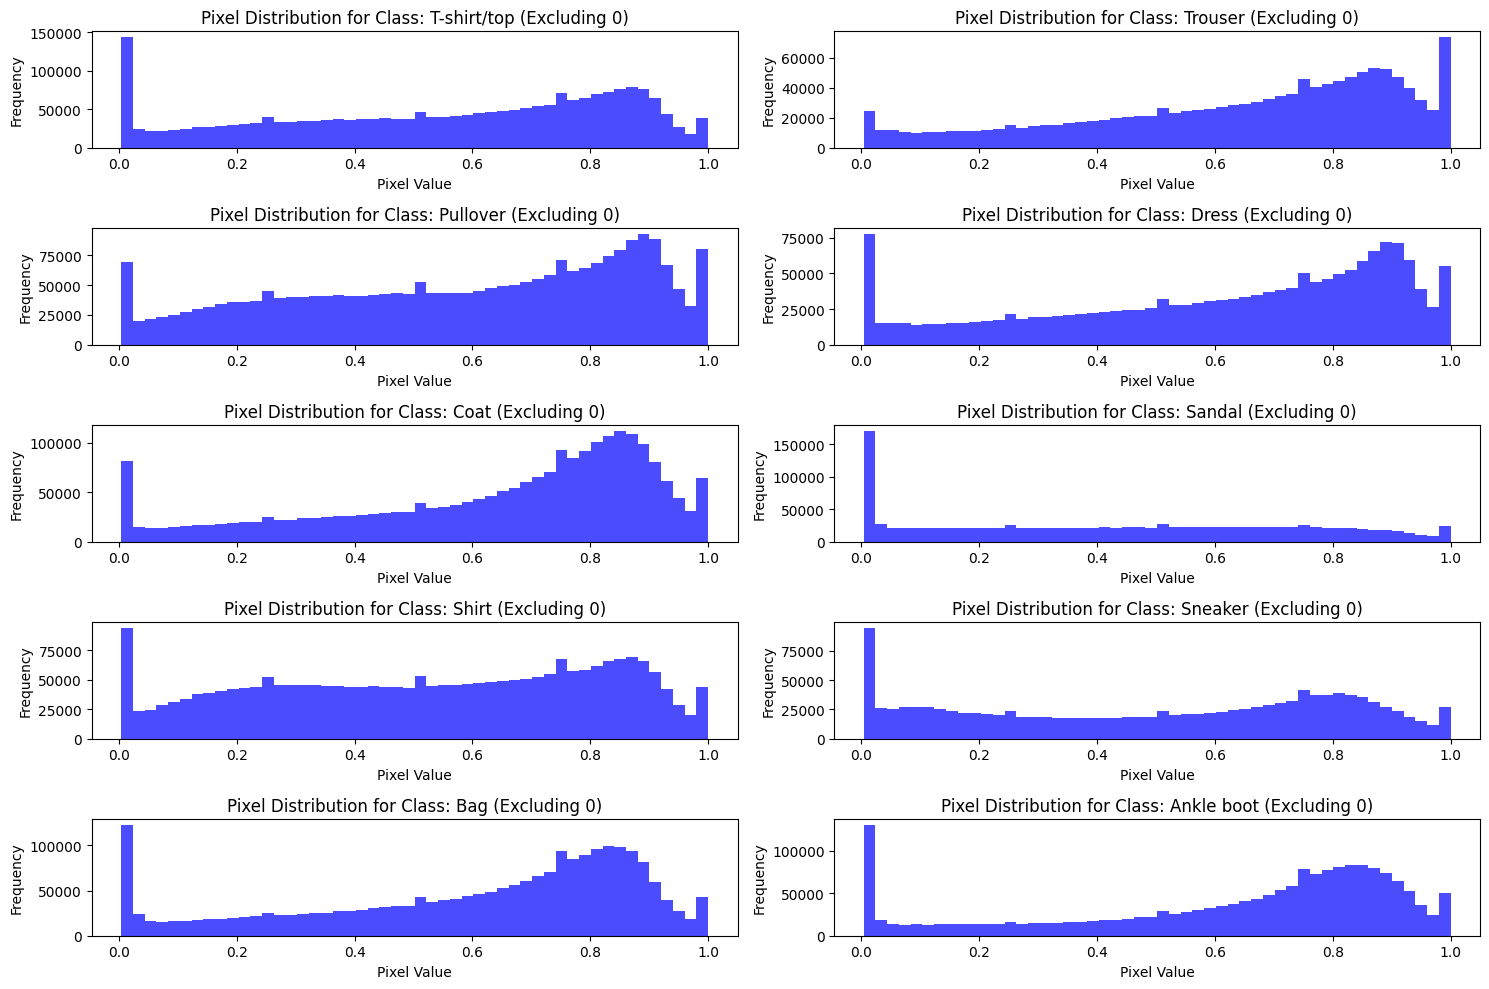

In [ ]:
# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images_scaled, train_labels, class_names)

### Heat map for correlation label

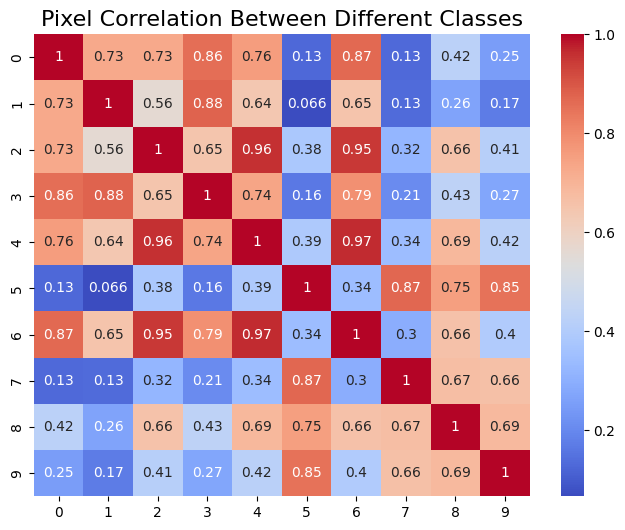

In [ ]:
# Built correlation matrix

# Calculate the correlation matrix between classes
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_images[i])

# Calculate the average image of each layer
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Calculate the correlation matrix between classes
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

> The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes.

### HOG feature extraction

> `HOG (Histogram of Oriented Gradients)` is a feature extraction method for images, designed to capture structural and shape information about objects in the image, regardless of slight changes like lighting or viewpoint.
* **Gradient:** At each pixel in the image, a gradient represents the change in intensity along different directions (e.g., up, down, left, right). Gradients highlight edges and contours in the image, which are critical for identifying object boundaries.
* **Oriented Gradients:** HOG calculates and groups gradient directions into bins that represent specific orientations (e.g., 8 orientations: 0°, 45°, 90°, etc.).
* **Histogram:** Each small cell in the image (e.g.,2x2, 4x4, 8x8 pixels) generates a histogram that captures the gradient directions within that cell. The result is a feature vector that describes the local structure of the image, making HOG effective for tasks such as object detection and recognition.

> **HOG Features:**
* Focused on Gradient Directions: Rather than focusing on raw pixel values, HOG extracts features based on the gradient direction at each pixel and aggregates this information over regions in the image. Instead of simply capturing pixel values, HOG emphasizes the shape and edges of objects, which are crucial for object recognition.
* Noise Resistance: HOG features are more resistant to noise, as they are less affected by minor changes in pixel intensity or positioning. This makes the model more robust to slight variations in brightness or object position.

> **Trade-offs when Reducing Feature Count:**
* Reduced Noise: Reducing feature count helps in filtering out noise. Raw pixel values don’t provide much structural information about the object and can contain a lot of noise. HOG reduces this noise by retaining key shape and edge information, making object recognition easier for the model.
* Computational Efficiency: Fewer features lead to faster processing, as machine learning models handle less data. This is particularly important for computationally intensive models like SVM or Logistic Regression.
Improved Generalization: Reducing feature count can enhance a model’s ability to generalize on new data since it focuses more on the object’s overall structure rather than individual pixel details.
* Potential Downsides: Over-reducing the feature count may lead to a loss of crucial information if HOG features do not sufficiently capture the necessary details of the image.

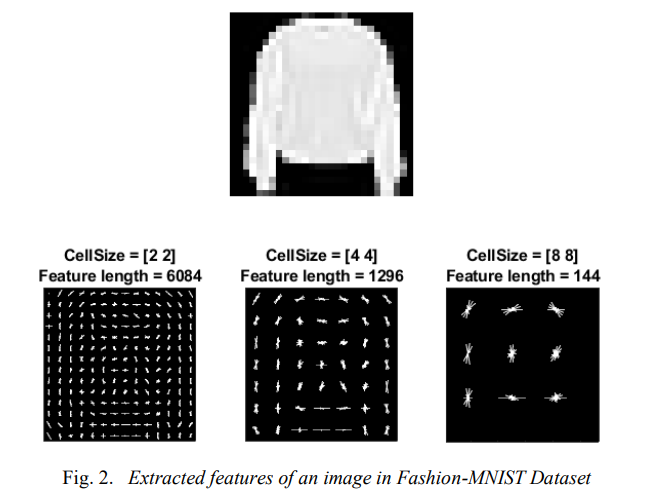

> In Figure 2 extracted HOG features of one image using
three different cell sizes are shown. In this figure the
visualization of cell size [2 2], [4 4] and [8 8] are shown.
From that it is clearly understood that the cell size [2 2]
contains more shape information than the cell size of [8 8] in
their visualization. But in the latter case the dimensionality of
feature vector using HOG increases comparing with the
former. A good choice is the [4 4] cell size. By using this size
the numbers of dimensions are limited and this helps to speed
up the training process. Also it contains enough information
to visualize the fashion image shape. For identifying the
suitable parameter setting configuration of HOG parameters
more training and testing processes using the classifier has to
be performed.

In [ ]:
# demo with cell size of [4 4]
def apply_hog(images):
    hog_features = []
    for image in images:
        image_reshaped = image.reshape(28, 28)
        hog_feature = hog(image_reshaped, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=False)
        hog_features.append(hog_feature)
    return np.array(hog_features)

train_hog_4 = apply_hog(train_images_scaled)
val_hog_4 = apply_hog(val_images_scaled)
test_hog_4 = apply_hog(test_images_scaled)

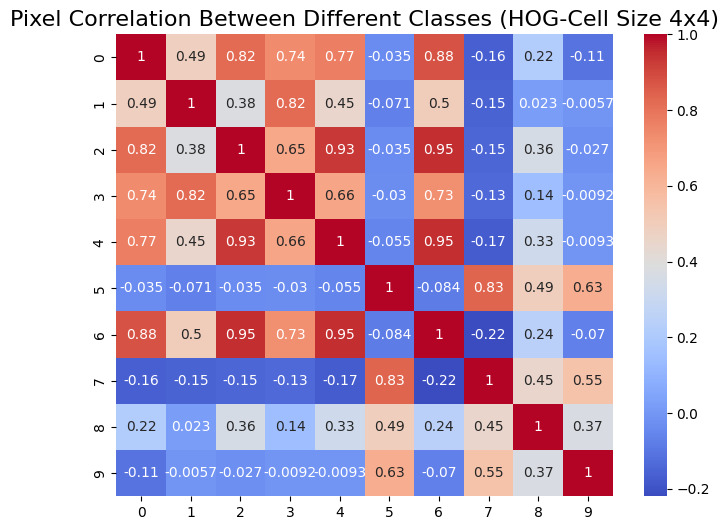

In [ ]:
# Compute the inter-class correlation matrix as before
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_hog_4[i])

mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes (HOG-Cell Size 4x4)", fontsize=16)
plt.show()

In [ ]:
# demo with cell size of [2 2]
def apply_hog(images):
    hog_features = []
    for image in images:
        image_reshaped = image.reshape(28, 28)
        hog_feature = hog(image_reshaped, pixels_per_cell=(2, 2), cells_per_block=(2, 2), visualize=False)
        hog_features.append(hog_feature)
    return np.array(hog_features)

train_hog_2 = apply_hog(train_images_scaled)
val_hog_2 = apply_hog(val_images_scaled)
test_hog_2 = apply_hog(test_images_scaled)

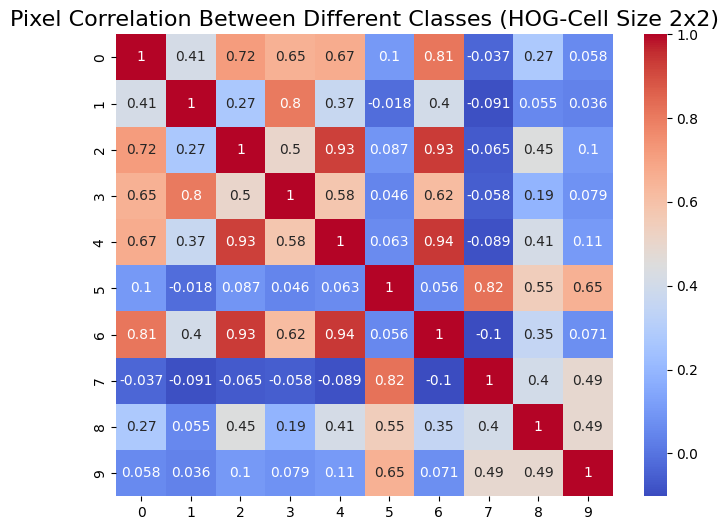

In [ ]:
# Compute the inter-class correlation matrix as before
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_hog_2[i])

mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes (HOG-Cell Size 2x2)", fontsize=16)
plt.show()

> `Cell 4x4:`
* The matrix with a 4x4 cell shows strong correlation between classes, especially for pairs of classes with high similarity, such as classes 0 and 2, and classes 4 and 2. This indicates that HOG features with a 4x4 cell capture significant details related to the geometric characteristics of samples within each class.
* However, this high correlation between classes can lead to greater confusion among classes in a classification model.

> `Cell 2x2:`
* The matrix with a 2x2 cell shows a lower level of correlation between classes. This suggests that HOG features with higher resolution (smaller cell size) can better differentiate between classes.
* The 2x2 cell tends to be more detailed since each cell is smaller; therefore, it can capture finer features but may reduce the generalizability of the features.


>Depending on the objective of the task, choose either Cell 2x2 or Cell 4x4.

> **Objective:** Minimize confusion between classes => Therefore, I decided to use Cell 2x2.

>The changes in correlation reflect that HoG preprocessing effectively captures texture and edge features. Lower or negative correlations show that HoG might be helping to differentiate between some classes that have similar pixel intensities but different structures.
 **=> We'll build the model and perform to clearly see the impact**

## Demo Logistic Regression

> In multiclass classification problem like Fashion-MNIST, when using Logistic Regression, choosing the right solver and classification strategy (like `multinomial` or `OvR`) is very important to optimize performance and speed.

> Best Hyperparameters for solver and multi_class with LogisticRegression. Try different values ​​of `solver` and `multi_class` to find the optimal configuration.




We have a multi_class problem with a larg dataset 60k samples, we scaled the data (pre-condition), and we can use `OvR` or `multinomial`, OvR would make 9 classifiers as we had 9 classes, and multinomial use one classifier and minimize the mutli-class loss such as Cross-Entropy (log-loss) anyway the 'auto' option would deal with this as some solvers won't work with some options.

Solvers we may use

1. `libfgs` ❌ slow, not suitable for larg datasets (default)
2. `liblinear` ❌ slow, not suitable for larg datasets
3. `newton-cg` ✅ let's give it a try
4. `sag` ✅ good but ..saga is faster
5. `saga` ✅ let's give it a try
6. `newton-cholesky` ❌ prefered when (samples (rows=60k) >> features (cols=0.785k)) but calculate Hessian may make it slow


[Reference](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

### LR basic with method OvR using train_images_scaled

In [ ]:
model = LogisticRegression(multi_class='ovr', solver='saga', max_iter=100, random_state=42)

# Train the model
model.fit(train_images_scaled, train_labels)

# Predict on test data
test_predictions = model.predict(test_images_scaled)

In [ ]:
accuracy = accuracy_score(test_labels, test_predictions)
precision = precision_score(test_labels, test_predictions, average='macro')
recall = recall_score(test_labels, test_predictions, average='macro')
f1 = f1_score(test_labels, test_predictions, average='macro')

In [ ]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.8423
Precision: 0.8400731155504688
Recall: 0.8423
F1 Score: 0.8405050317554899


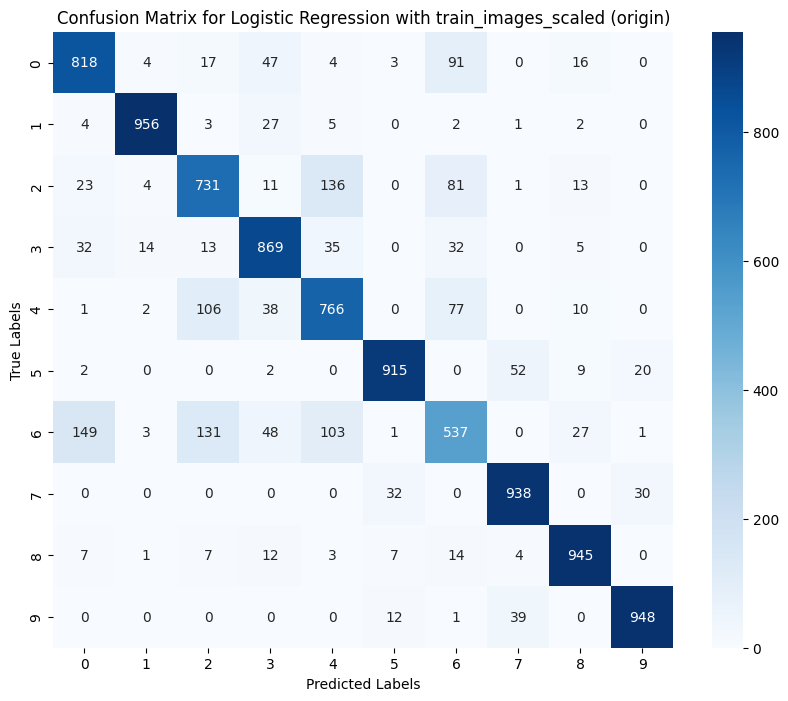

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Logistic Regression with train_images_scaled (origin)')
plt.show()

### LR basic with method OvR using train_hog (using Hog preprocessing to reduce pixel correlation coefficient)

In [ ]:
model_hog = LogisticRegression(multi_class='ovr', solver='saga', max_iter=100, random_state=42)

# Train the model
model_hog.fit(train_hog_2, train_labels)

In [ ]:
# predict
test_predictions_hog = model_hog.predict(test_hog_2)

In [ ]:
accuracy_hog = accuracy_score(test_labels, test_predictions_hog)
precision_hog = precision_score(test_labels, test_predictions_hog, average='macro')
recall_hog = recall_score(test_labels, test_predictions_hog, average='macro')
f1_hog = f1_score(test_labels, test_predictions_hog, average='macro')

In [ ]:
print(f"Accuracy: {accuracy_hog}")
print(f"Precision: {precision_hog}")
print(f"Recall: {recall_hog}")
print(f"F1 Score: {f1_hog}")

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_predictions_hog)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Logistic Regression with Train_hog')
plt.show()

When using Hog Preprocessing to reduce the correlation coefficient, the Model will be significantly more effective